In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
dataframe = pd.read_csv('../assets/seeds_11/train_11.csv')
dataframe.head()
dataframe.info()
dataframe.describe()
X = dataframe.drop(columns=['label'])

<class 'pandas.DataFrame'>
RangeIndex: 87447 entries, 0 to 87446
Columns: 513 entries, 0 to label
dtypes: float64(512), int64(1)
memory usage: 342.3 MB


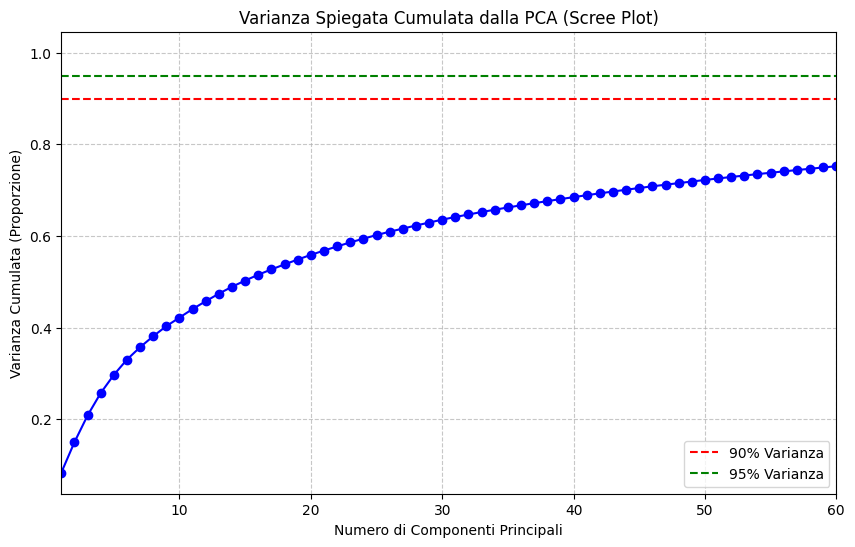

In [3]:
# 1. Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)

# 2. Inizializza la PCA SENZA specificare il numero di componenti.
# In questo modo calcolerà tutte le 512 componenti (o min(n_samples, n_features)).
pca = PCA()
pca.fit(X_train_scaled)

# 3. Estrai la proporzione di varianza spiegata da ogni singola componente
# e calcola la somma cumulativa
varianza_singola = pca.explained_variance_ratio_
varianza_cumulata = np.cumsum(varianza_singola)

# 4. Creazione del Grafico (Scree Plot)
plt.figure(figsize=(10, 6))

# Plotta la curva della varianza cumulata
plt.plot(range(1, len(varianza_cumulata) + 1), varianza_cumulata, marker='o', linestyle='-', color='b')
plt.xlim(1, 60)

# Aggiungi linee di riferimento (es. per il 90% e il 95% della varianza)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Varianza')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Varianza')

# Estetica del grafico
plt.title('Varianza Spiegata Cumulata dalla PCA (Scree Plot)')
plt.xlabel('Numero di Componenti Principali')
plt.ylabel('Varianza Cumulata (Proporzione)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

In [4]:
PCA_32 = PCA(n_components=32)
X_train_pca_32 = PCA_32.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 32 componenti: {PCA_32.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 32 componenti: 0.6470


In [5]:
PCA_16 = PCA(n_components=16)
X_train_pca_16 = PCA_16.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 16 componenti: {PCA_16.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 16 componenti: 0.5155


In [6]:
PCA_8 = PCA(n_components=8)
X_train_pca_8 = PCA_8.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 8 componenti: {PCA_8.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 8 componenti: 0.3812


In [7]:
PCA_4 = PCA(n_components=4)
X_train_pca_4 = PCA_4.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 4 componenti: {PCA_4.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 4 componenti: 0.2571


In [8]:
import skops.io as sio
from utils import ASSETS_DIR
sio.dump(PCA_32, f'{ASSETS_DIR}/seeds_11/pca_32.skops')
sio.dump(PCA_16, f'{ASSETS_DIR}/seeds_11/pca_16.skops')
sio.dump(PCA_8, f'{ASSETS_DIR}/seeds_11/pca_8.skops')
sio.dump(PCA_4, f'{ASSETS_DIR}/seeds_11/pca_4.skops')   
sio.dump(scaler, f'{ASSETS_DIR}/seeds_11/scaler.skops')

La root del progetto è: /home/kirjia/ProgettoQuantumBioetria/src
